In [1]:
# Import libraries
import pandas as pd
import sqlite3

# Load data
df = pd.read_excel("/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw/Demographic-aspects-2023.xlsx", header=1)

# Clean columns of dataset
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

# Remove unwanted columns
df =  df.loc[:, ~df.columns.str.contains(r"^Unnamed", na=False)]
df = df.loc[:, df.columns.notna()]
df = df.loc[:, df.columns != "nan"]

# Verify cleaning steps
print(df.columns.tolist())

# Check for duplicates
print("Duplicate columns:", df.columns[df.columns.duplicated()].tolist())

# Transform from wide to long format
df_long = df.melt(
    id_vars = ["Key Demographic aspects", "Unit"],
    var_name = "year",
    value_name = "value"
)

display(df_long.head())


# Connect to SQLite3
conn = sqlite3.connect("population.db")

# Save table
df_long.to_sql("population", conn, if_exists="replace", index=False)

['Key Demographic aspects', 'Unit', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
Duplicate columns: []


,Key Demographic aspects,Unit,year,value
0,Males,Absolute,2015,51309.0
1,Females,Absolute,2015,57326.0
2,Total population,Absolute,2015,108635.0
3,Sex ratio,NaN,2015,89.5
4,Pop. per km2 land,Absolute,2015,604.0


108

In [2]:
# Simple query, total by year
query = """
SELECT year, SUM(value) as total
FROM population
GROUP BY year
ORDER BY year
"""

result = pd.read_sql(query, conn)

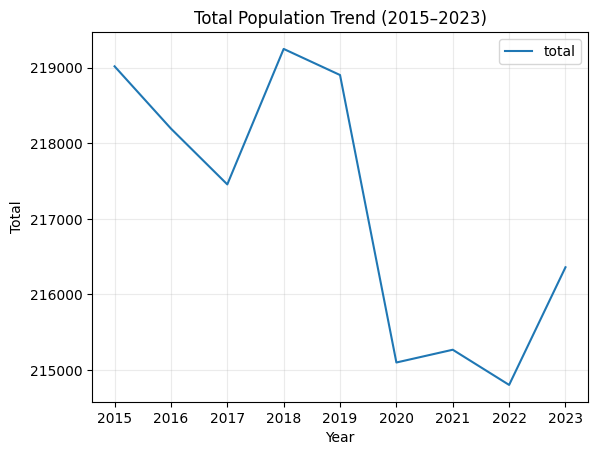

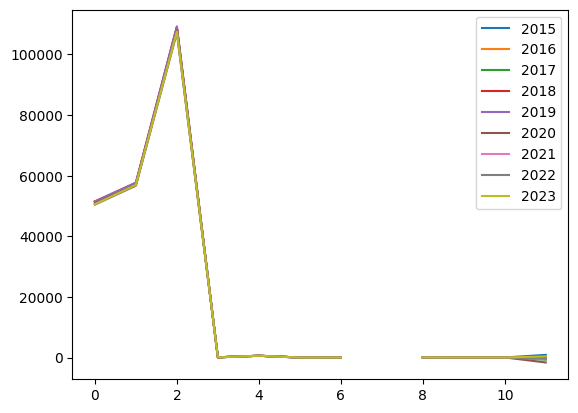

In [3]:
# Simple plot
result["year"] = result["year"].astype(int)

ax = result.plot(x="year", y="total", kind="line", title=("Total Population Trend (2015–2023)"))
ax.set_xlabel("Year")
ax.set_ylabel("Total")
ax.grid(True, alpha=0.25)

ax = df.plot()
fig = ax.get_figure()

fig.savefig("sqlite_viz.png")

conn.close()